# Notebook 04: Feature-Based ML Models (Random Forest & XGBoost)

**Project:** Forecasting Religious Tourism — ML Analysis of Pilgrimage Patterns to Sacred Sites in Nepal

**Purpose:** Train Random Forest and XGBoost models using external features (weather, festivals, seasons) alongside visitor data. Compare their accuracy with the ARIMA/SARIMA models from Notebook 03.

**Input:** `../data/pilgrimage_data_clean.csv`

**Output:** Trained models saved as `.pkl` files in `../models/` folder

---

### How are these different from ARIMA/SARIMA?

ARIMA and SARIMA only look at the visitor count sequence. They answer: *"Based on past visitor numbers alone, what comes next?"*

Random Forest and XGBoost take in **multiple input features**: temperature, rainfall, whether a festival falls in that month, the season, and the month number. They answer: *"Given these specific conditions, how many visitors should we expect?"*

This is the core comparison of the thesis: **can external features improve forecasting accuracy beyond what the time series alone can achieve?**

In [2]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB 330.3 kB/s eta 0:05:08
   ---------------------------------------- 0.1/101.7 MB 787.7 kB/s eta 0:02:09
   ---------------------------------------- 0.3/101.7 MB 2.5 MB/s eta 0:00:42
   ---------------------------------------- 0.8/101.7 MB 4.8 MB/s eta 0:00:22
    --------------------------------------- 1.4/101.7 MB 6.2 MB/s eta 0:00:17
    --------------------------------------- 2.0/101.7 MB 7.5 MB/s eta 0:00:14
   - -------------------------------------- 2.8/101.7 MB 8.8 MB/s eta 0:00:12
   - -------------------------------------- 3.2/101.7 MB 9.3 MB/s eta 0:00:11
   - -------------------------------------- 3.9/101.7 MB 9.7 MB/s eta 0:00:11
   - -------------------------------------- 4.2/101.7 MB 9.3 MB/s eta 0:00:11
   - -------------------------------------- 4.2/101.7 MB 9.3 MB/s eta 0:00:11
   - -------------------------------------- 4.2/101.7 MB 9.3 MB/s e


[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 1: Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# ML models
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# For accuracy metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# For saving models
import joblib
import os

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
warnings.filterwarnings('ignore')

os.makedirs('../models', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

print('Libraries imported successfully')

Libraries imported successfully


## Step 2: Load Clean Data

In [4]:
# Load cleaned data
df = pd.read_csv('../data/pilgrimage_data_clean.csv')

# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

sites = sorted(df['site'].unique())
print(f'Sites: {sites}')
print(f'Rows: {len(df)}')
print(f'Columns: {list(df.columns)}')

Sites: ['Janakpur Dham', 'Lumbini', 'Muktinath', 'Pashupatinath']
Rows: 756
Columns: ['date', 'site', 'total_visitors', 'domestic_visitors', 'indian_visitors', 'international_visitors', 'temperature_c', 'rainfall_mm', 'festival', 'season']


## Step 3: Feature Engineering

This is the most important step for ML models. We create the input features that Random Forest and XGBoost will learn from. Good features = better predictions.

**Features we create:**
- `month` — which month (1-12). Captures monthly seasonality directly.
- `year` — which year. Captures growth trends over time.
- `temperature_c` — monthly average temperature. Already in the data.
- `rainfall_mm` — monthly rainfall. Already in the data.
- `festival` — 1 if major festival that month, 0 otherwise. Already in the data.
- `season_*` — one-hot encoded season columns. Converts 'monsoon', 'winter' etc. into separate 0/1 columns.
- `lag_1` — visitor count from the previous month. Gives the model recent context.
- `lag_12` — visitor count from the same month last year. Captures yearly repetition.
- `rolling_3` — average visitors over the last 3 months. Smooths out short-term noise.

In [5]:
# Extract time-based features
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

# One-hot encode seasons (converts 'monsoon' etc. to separate 0/1 columns)
season_dummies = pd.get_dummies(df['season'], prefix='season')
df = pd.concat([df, season_dummies], axis=1)

# Create lag features (previous months' visitor counts)
# We do this per site so that one site's data doesn't leak into another
df = df.sort_values(['site', 'date']).reset_index(drop=True)

df['lag_1'] = df.groupby('site')['total_visitors'].shift(1)    # Last month
df['lag_12'] = df.groupby('site')['total_visitors'].shift(12)  # Same month last year
df['rolling_3'] = df.groupby('site')['total_visitors'].transform(
    lambda x: x.shift(1).rolling(window=3).mean()              # 3-month rolling average
)

# Show the new features
print('NEW FEATURES CREATED:')
print(f'Columns: {list(df.columns)}')
print(f'\nSample with lag features (first site):')
df[df['site'] == sites[0]][['date', 'site', 'total_visitors', 'lag_1', 'lag_12', 'rolling_3']].head(15)

NEW FEATURES CREATED:
Columns: ['date', 'site', 'total_visitors', 'domestic_visitors', 'indian_visitors', 'international_visitors', 'temperature_c', 'rainfall_mm', 'festival', 'season', 'month', 'year', 'season_monsoon', 'season_post-monsoon', 'season_pre-monsoon', 'season_winter', 'lag_1', 'lag_12', 'rolling_3']

Sample with lag features (first site):


,date,site,total_visitors,lag_1,lag_12,rolling_3
0,2010-01-01,Janakpur Dham,8037,NaN,NaN,NaN
1,2010-02-01,Janakpur Dham,9547,8037.0,NaN,NaN
2,2010-03-01,Janakpur Dham,15966,9547.0,NaN,NaN
3,2010-05-01,Janakpur Dham,9066,15966.0,NaN,11183.333333
4,2010-06-01,Janakpur Dham,6300,9066.0,NaN,11526.333333
5,2010-07-01,Janakpur Dham,4789,6300.0,NaN,10444.000000
6,2010-08-01,Janakpur Dham,5324,4789.0,NaN,6718.333333
7,2010-09-01,Janakpur Dham,8415,5324.0,NaN,5471.000000
8,2010-10-01,Janakpur Dham,8980,8415.0,NaN,6176.000000
9,2010-11-01,Janakpur Dham,20559,8980.0,NaN,7573.000000


## Step 4: Handle Missing Values from Lag Features

Creating lag features introduces NaN values at the beginning of each site's data (because there is no "previous month" for the first row, and no "same month last year" for the first 12 rows). We drop these rows since they cannot be used for training.

In [6]:
# Check NaN counts before dropping
print('NaN counts before dropping:')
print(df[['lag_1', 'lag_12', 'rolling_3']].isnull().sum())
print(f'Total rows before: {len(df)}')

# Drop rows where lag features are NaN
df_ml = df.dropna(subset=['lag_1', 'lag_12', 'rolling_3']).copy()

print(f'\nTotal rows after dropping NaN lags: {len(df_ml)}')
print(f'Rows removed: {len(df) - len(df_ml)} (first 12 months per site)')

NaN counts before dropping:
lag_1         4
lag_12       48
rolling_3    12
dtype: int64
Total rows before: 756

Total rows after dropping NaN lags: 708
Rows removed: 48 (first 12 months per site)


## Step 5: Define Features and Target

We select which columns are **features** (inputs the model learns from) and which is the **target** (what we want to predict).

In [7]:
# Define feature columns
feature_columns = [
    'month',            # Which month (1-12)
    'year',             # Which year (captures growth trend)
    'temperature_c',    # Monthly temperature
    'rainfall_mm',      # Monthly rainfall
    'festival',         # Festival flag (0 or 1)
    'lag_1',            # Last month's visitors
    'lag_12',           # Same month last year's visitors
    'rolling_3',        # 3-month rolling average
]

# Add season dummy columns
season_cols = [col for col in df_ml.columns if col.startswith('season_')]
feature_columns.extend(season_cols)

# Target column
target_column = 'total_visitors'

print(f'Feature columns ({len(feature_columns)}):')
for col in feature_columns:
    print(f'  - {col}')
print(f'\nTarget: {target_column}')

Feature columns (12):
  - month
  - year
  - temperature_c
  - rainfall_mm
  - festival
  - lag_1
  - lag_12
  - rolling_3
  - season_monsoon
  - season_post-monsoon
  - season_pre-monsoon
  - season_winter

Target: total_visitors


## Step 6: Train-Test Split

We use the **same time-based split** as Notebook 03: train on 2010-2022, test on 2023-2025. This ensures a fair comparison between time series models and ML models.

In [8]:
# Same split as Notebook 03
TRAIN_END = '2022-12-31'
TEST_START = '2023-01-01'

train_data = df_ml[df_ml['date'] <= TRAIN_END]
test_data = df_ml[df_ml['date'] >= TEST_START]

print(f'Training rows: {len(train_data)} (2010 to 2022)')
print(f'Testing rows:  {len(test_data)} (2023 to 2025)')
print(f'\nTraining sites: {train_data["site"].nunique()}')
print(f'Testing sites:  {test_data["site"].nunique()}')

Training rows: 569 (2010 to 2022)
Testing rows:  139 (2023 to 2025)

Training sites: 4
Testing sites:  4


## Step 7: Define Accuracy Metrics

In [9]:
def calculate_metrics(actual, predicted):
    """Calculate MAE, RMSE, and MAPE — same function as Notebook 03"""
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return {'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'MAPE': round(mape, 2)}

print('Metrics function ready.')

Metrics function ready.


## Step 8: Train Random Forest Models

Random Forest builds hundreds of decision trees, each trained on a random subset of the data and features. The final prediction is the average of all trees. This makes it robust against overfitting.

**Key parameters:**
- `n_estimators=200` — build 200 trees (more trees = more stable predictions)
- `max_depth=10` — each tree can be at most 10 levels deep (prevents overfitting)
- `random_state=42` — fixed seed so results are reproducible

Janakpur Dham: MAE=4,138, RMSE=6,202, MAPE=16.52%
Lumbini: MAE=12,372, RMSE=15,123, MAPE=13.72%
Muktinath: MAE=1,468, RMSE=1,820, MAPE=19.02%
Pashupatinath: MAE=13,039, RMSE=18,776, MAPE=13.16%


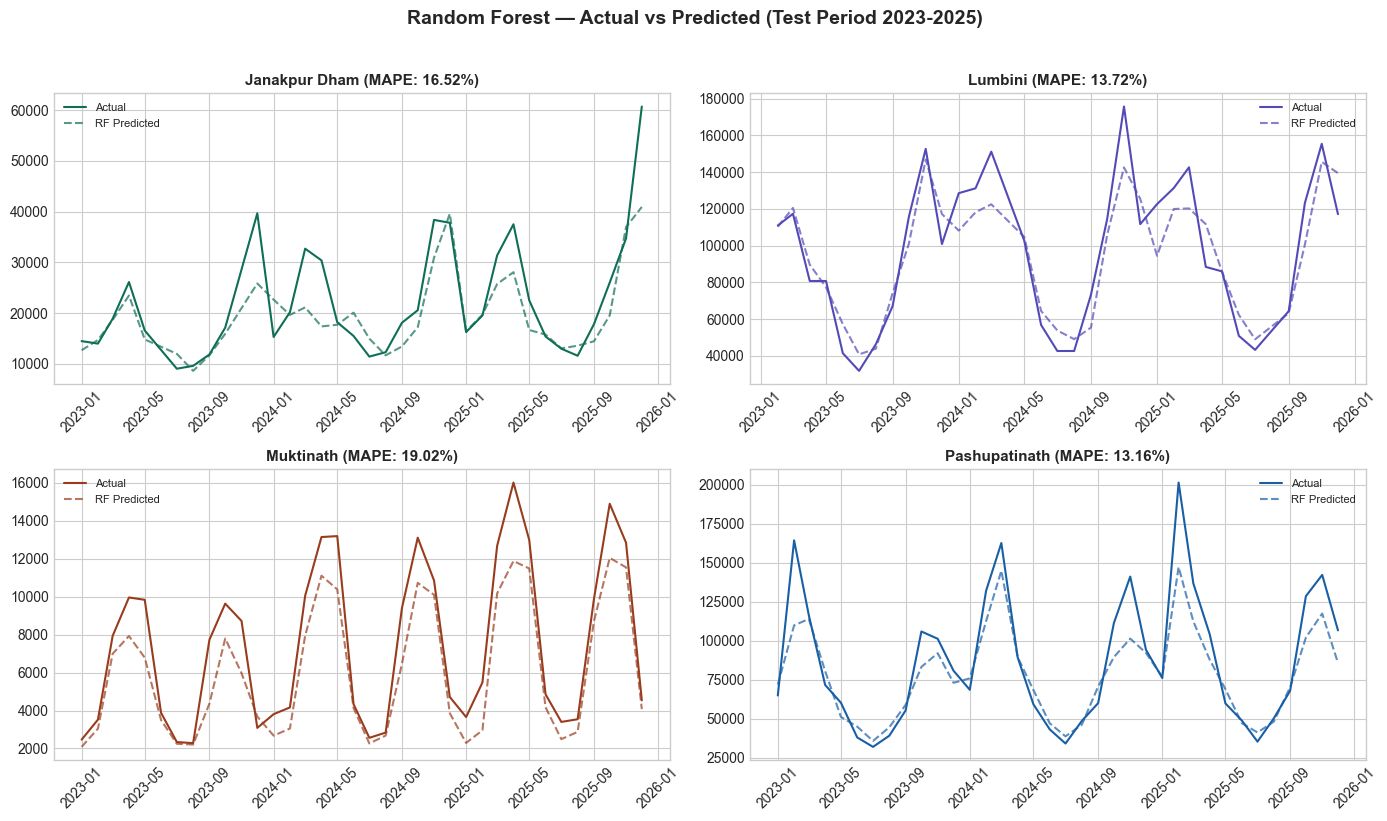


All Random Forest models trained and saved.


In [10]:
# Store results
rf_results = {}
rf_models = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Random Forest — Actual vs Predicted (Test Period 2023-2025)', 
             fontsize=14, fontweight='bold', y=1.02)

colors = ['#0F6E56', '#534AB7', '#993C1D', '#185FA5']

for i, (site, color) in enumerate(zip(sites, colors)):
    ax = axes[i // 2, i % 2]
    
    # Get train and test data for this site
    site_train = train_data[train_data['site'] == site]
    site_test = test_data[test_data['site'] == site]
    
    # Prepare features (X) and target (y)
    X_train = site_train[feature_columns]
    y_train = site_train[target_column]
    X_test = site_test[feature_columns]
    y_test = site_test[target_column]
    
    # Train Random Forest
    rf = RandomForestRegressor(
        n_estimators=200,    # 200 trees
        max_depth=10,        # Maximum tree depth
        min_samples_split=5, # Minimum samples to split a node
        random_state=42      # For reproducibility
    )
    rf.fit(X_train, y_train)
    
    # Predict on test data
    predictions = rf.predict(X_test)
    
    # Calculate metrics
    metrics = calculate_metrics(y_test.values, predictions)
    rf_results[site] = metrics
    rf_models[site] = rf
    
    # Save model
    joblib.dump(rf, f'../models/rf_{site.lower().replace(" ", "_")}.pkl')
    
    # Plot
    test_dates = site_test['date'].values
    ax.plot(test_dates, y_test.values, color=color, linewidth=1.5, label='Actual')
    ax.plot(test_dates, predictions, color=color, linewidth=1.5, 
            linestyle='--', alpha=0.7, label='RF Predicted')
    ax.set_title(f'{site} (MAPE: {metrics["MAPE"]}%)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)
    
    print(f'{site}: MAE={metrics["MAE"]:,.0f}, RMSE={metrics["RMSE"]:,.0f}, MAPE={metrics["MAPE"]}%')

plt.tight_layout()
plt.savefig('../outputs/17_rf_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nAll Random Forest models trained and saved.')

## Step 9: Train XGBoost Models

XGBoost builds trees one after another. Each new tree focuses on correcting the mistakes of all previous trees. This sequential error-correction makes XGBoost extremely accurate.

**Key parameters:**
- `n_estimators=200` — build 200 trees sequentially
- `max_depth=6` — shallower than RF because each tree corrects errors rather than learning independently
- `learning_rate=0.1` — how quickly the model adapts (smaller = more careful, less overfitting)

Janakpur Dham: MAE=3,944, RMSE=5,928, MAPE=15.45%
Lumbini: MAE=13,895, RMSE=17,925, MAPE=14.09%
Muktinath: MAE=2,076, RMSE=2,640, MAPE=24.91%
Pashupatinath: MAE=15,198, RMSE=21,308, MAPE=14.91%


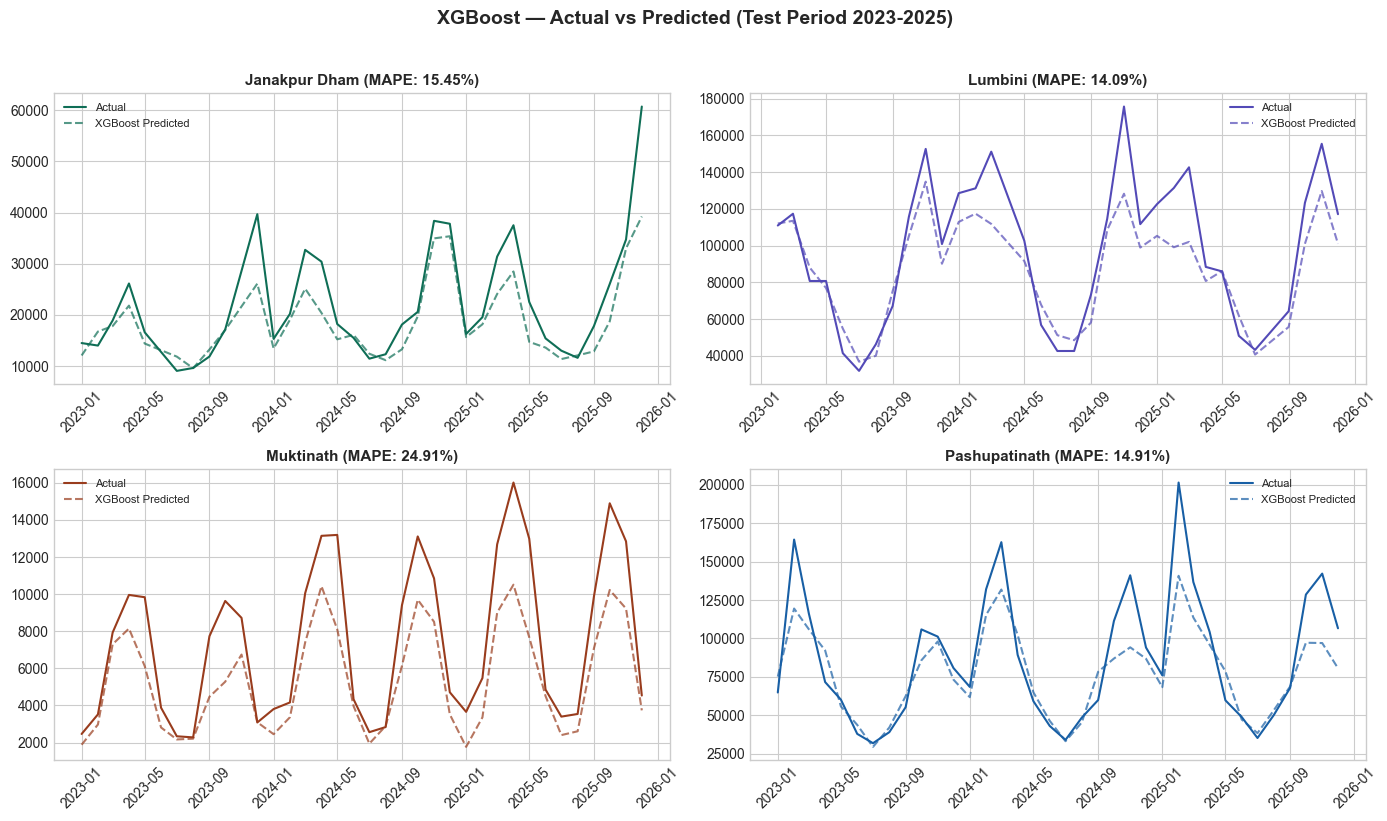


All XGBoost models trained and saved.


In [11]:
# Store results
xgb_results = {}
xgb_models = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('XGBoost — Actual vs Predicted (Test Period 2023-2025)', 
             fontsize=14, fontweight='bold', y=1.02)

for i, (site, color) in enumerate(zip(sites, colors)):
    ax = axes[i // 2, i % 2]
    
    # Get train and test data for this site
    site_train = train_data[train_data['site'] == site]
    site_test = test_data[test_data['site'] == site]
    
    # Prepare features (X) and target (y)
    X_train = site_train[feature_columns]
    y_train = site_train[target_column]
    X_test = site_test[feature_columns]
    y_test = site_test[target_column]
    
    # Train XGBoost
    xgb = XGBRegressor(
        n_estimators=200,     # 200 boosting rounds
        max_depth=6,          # Maximum tree depth
        learning_rate=0.1,    # Step size for each correction
        subsample=0.8,        # Use 80% of data per tree (reduces overfitting)
        colsample_bytree=0.8, # Use 80% of features per tree
        random_state=42       # For reproducibility
    )
    xgb.fit(X_train, y_train, verbose=False)  # verbose=False hides training output
    
    # Predict on test data
    predictions = xgb.predict(X_test)
    
    # Calculate metrics
    metrics = calculate_metrics(y_test.values, predictions)
    xgb_results[site] = metrics
    xgb_models[site] = xgb
    
    # Save model
    joblib.dump(xgb, f'../models/xgb_{site.lower().replace(" ", "_")}.pkl')
    
    # Plot
    test_dates = site_test['date'].values
    ax.plot(test_dates, y_test.values, color=color, linewidth=1.5, label='Actual')
    ax.plot(test_dates, predictions, color=color, linewidth=1.5, 
            linestyle='--', alpha=0.7, label='XGBoost Predicted')
    ax.set_title(f'{site} (MAPE: {metrics["MAPE"]}%)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)
    
    print(f'{site}: MAE={metrics["MAE"]:,.0f}, RMSE={metrics["RMSE"]:,.0f}, MAPE={metrics["MAPE"]}%')

plt.tight_layout()
plt.savefig('../outputs/18_xgb_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nAll XGBoost models trained and saved.')

## Step 10: Feature Importance Analysis

One of the biggest advantages of Random Forest and XGBoost over ARIMA/SARIMA is that they tell you **which features matter most**. This is valuable for thesis because I can say: "The model confirms that festivals are the primary driver at Pashupatinath" or "Rainfall is the most important factor at Muktinath."

This directly answers my research question about what factors influence pilgrimage patterns.

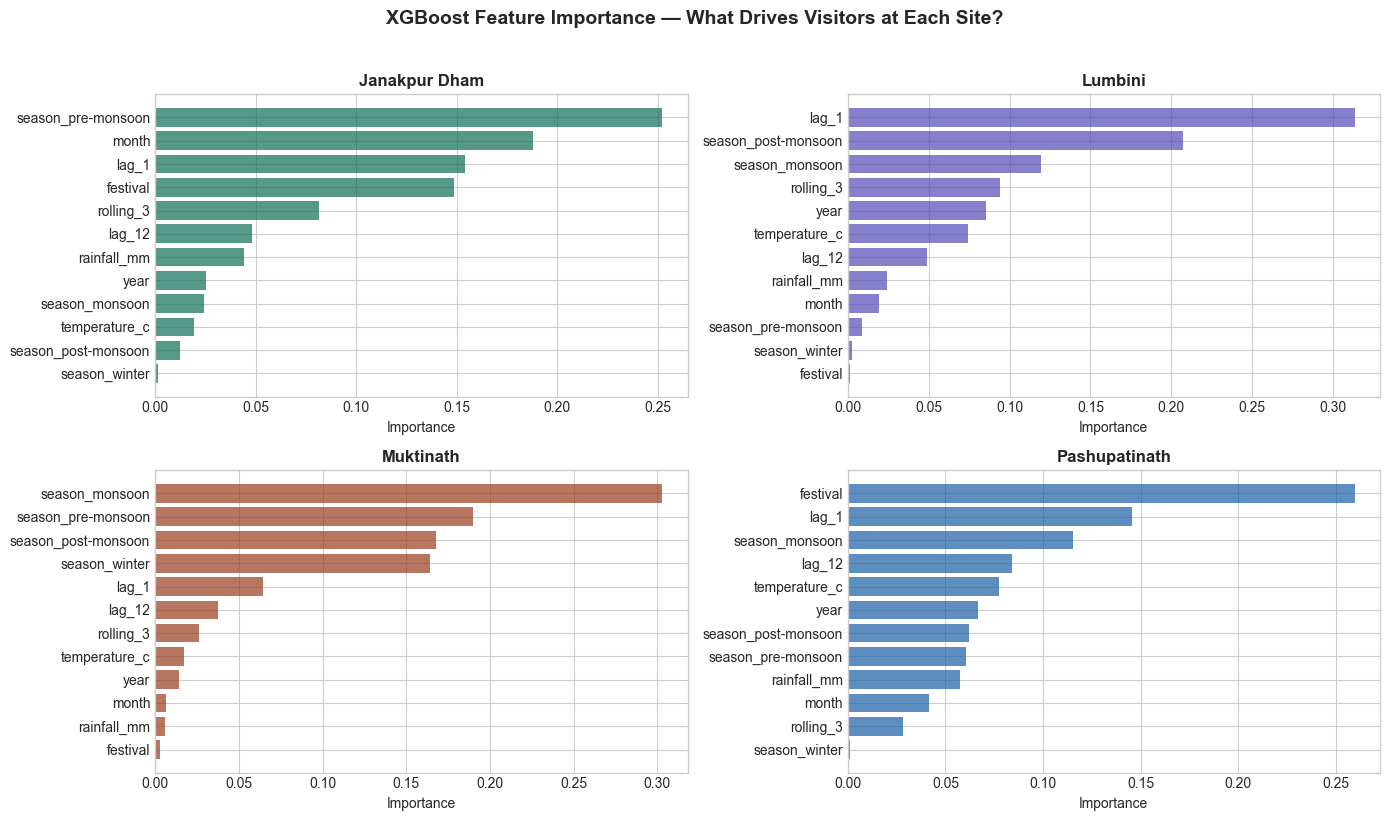

Feature importance charts generated.


In [12]:
# Feature importance from XGBoost (XGBoost importance is generally more reliable)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('XGBoost Feature Importance — What Drives Visitors at Each Site?', 
             fontsize=14, fontweight='bold', y=1.02)

for i, (site, color) in enumerate(zip(sites, colors)):
    ax = axes[i // 2, i % 2]
    
    # Get feature importance from the trained XGBoost model
    importance = xgb_models[site].feature_importances_
    
    # Create a dataframe and sort
    feat_imp = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': importance
    }).sort_values('Importance', ascending=True)  # ascending for horizontal bar
    
    # Plot horizontal bar chart
    ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=color, alpha=0.7)
    ax.set_title(site, fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('../outputs/19_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature importance charts generated.')

In [13]:
# Print top 3 features per site
print('TOP 3 MOST IMPORTANT FEATURES PER SITE')
print('=' * 60)

for site in sites:
    importance = xgb_models[site].feature_importances_
    feat_imp = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': importance
    }).sort_values('Importance', ascending=False)
    
    print(f'\n{site}:')
    for j, row in feat_imp.head(3).iterrows():
        print(f'  {row["Feature"]}: {row["Importance"]:.4f}')

TOP 3 MOST IMPORTANT FEATURES PER SITE

Janakpur Dham:
  season_pre-monsoon: 0.2523
  month: 0.1881
  lag_1: 0.1542

Lumbini:
  lag_1: 0.3132
  season_post-monsoon: 0.2074
  season_monsoon: 0.1194

Muktinath:
  season_monsoon: 0.3030
  season_pre-monsoon: 0.1901
  season_post-monsoon: 0.1676

Pashupatinath:
  festival: 0.2595
  lag_1: 0.1457
  season_monsoon: 0.1155


## Step 11: Random Forest vs XGBoost Comparison

Which ML model performed better at each site?

In [14]:
# Comparison table
ml_comparison = pd.DataFrame({
    'Site': sites,
    'RF MAE': [rf_results[s]['MAE'] for s in sites],
    'XGB MAE': [xgb_results[s]['MAE'] for s in sites],
    'RF RMSE': [rf_results[s]['RMSE'] for s in sites],
    'XGB RMSE': [xgb_results[s]['RMSE'] for s in sites],
    'RF MAPE': [rf_results[s]['MAPE'] for s in sites],
    'XGB MAPE': [xgb_results[s]['MAPE'] for s in sites],
})

ml_comparison['Better Model'] = ml_comparison.apply(
    lambda row: 'XGBoost' if row['XGB MAPE'] < row['RF MAPE'] else 'Random Forest', axis=1
)

print('RANDOM FOREST vs XGBOOST COMPARISON')
print('=' * 80)
print(ml_comparison.to_string(index=False))

# Save comparison
ml_comparison.to_csv('../outputs/ml_comparison.csv', index=False)
print('\nSaved to: ../outputs/ml_comparison.csv')

RANDOM FOREST vs XGBOOST COMPARISON
         Site   RF MAE  XGB MAE  RF RMSE  XGB RMSE  RF MAPE  XGB MAPE  Better Model
Janakpur Dham  4137.97  3944.42  6201.90   5928.04    16.52     15.45       XGBoost
      Lumbini 12372.40 13894.88 15122.74  17925.49    13.72     14.09 Random Forest
    Muktinath  1467.71  2076.13  1820.08   2639.80    19.02     24.91 Random Forest
Pashupatinath 13038.58 15198.35 18775.64  21308.20    13.16     14.91 Random Forest

Saved to: ../outputs/ml_comparison.csv


## Step 12: Visual Comparison — RF vs XGBoost

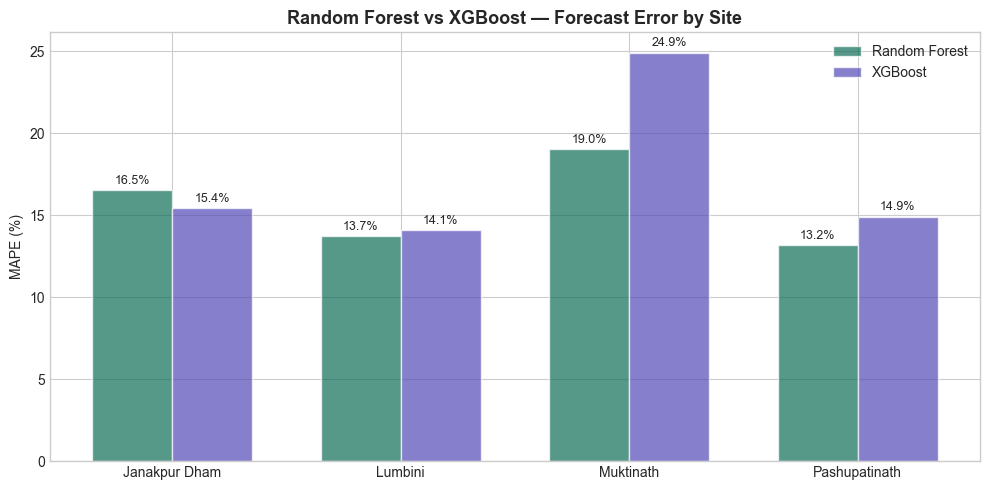

In [15]:
# Bar chart comparing MAPE
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(sites))
width = 0.35

bars1 = ax.bar(x - width/2, ml_comparison['RF MAPE'], width, 
               label='Random Forest', color='#0F6E56', alpha=0.7, edgecolor='white')
bars2 = ax.bar(x + width/2, ml_comparison['XGB MAPE'], width, 
               label='XGBoost', color='#534AB7', alpha=0.7, edgecolor='white')

# Value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('MAPE (%)')
ax.set_title('Random Forest vs XGBoost — Forecast Error by Site', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(sites)
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/20_rf_vs_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 13: Quick Preview — All Four Models

Before the full evaluation in Notebook 05, here is a quick look at all four models side by side. This preview tells us whether adding external features (RF, XGBoost) actually improved accuracy over using visitor counts alone (ARIMA, SARIMA).

In [16]:
# Load time series results from Notebook 03
try:
    ts_results = joblib.load('../models/time_series_results.pkl')
    arima_results = ts_results['arima']
    sarima_results = ts_results['sarima']
    
    # Build full comparison table
    full_comparison = pd.DataFrame({
        'Site': sites,
        'ARIMA': [arima_results[s]['MAPE'] for s in sites],
        'SARIMA': [sarima_results[s]['MAPE'] for s in sites],
        'Random Forest': [rf_results[s]['MAPE'] for s in sites],
        'XGBoost': [xgb_results[s]['MAPE'] for s in sites],
    })
    
    # Find overall best model per site
    model_cols = ['ARIMA', 'SARIMA', 'Random Forest', 'XGBoost']
    full_comparison['Best Model'] = full_comparison[model_cols].idxmin(axis=1)
    full_comparison['Best MAPE'] = full_comparison[model_cols].min(axis=1)
    
    print('ALL FOUR MODELS — MAPE COMPARISON (%)')
    print('=' * 80)
    print(full_comparison.to_string(index=False))
    
    # Save for Notebook 05
    full_comparison.to_csv('../outputs/full_model_comparison.csv', index=False)
    print('\nSaved to: ../outputs/full_model_comparison.csv')
    
except FileNotFoundError:
    print('Time series results not found. Run Notebook 03 first.')
    print('Showing only ML model results for now.')

ALL FOUR MODELS — MAPE COMPARISON (%)
         Site  ARIMA  SARIMA  Random Forest  XGBoost    Best Model  Best MAPE
Janakpur Dham  33.73   37.79          16.52    15.45       XGBoost      15.45
      Lumbini  32.22   41.97          13.72    14.09 Random Forest      13.72
    Muktinath  54.74   41.70          19.02    24.91 Random Forest      19.02
Pashupatinath  38.88   24.29          13.16    14.91 Random Forest      13.16

Saved to: ../outputs/full_model_comparison.csv


## Step 14: Save All Results

In [17]:
# Save ML results
ml_results = {
    'random_forest': rf_results,
    'xgboost': xgb_results
}
joblib.dump(ml_results, '../models/ml_results.pkl')

# Save feature columns list (needed by Streamlit app)
joblib.dump(feature_columns, '../models/feature_columns.pkl')

# List all saved files
print('SAVED FILES:')
print('=' * 50)
for f in sorted(os.listdir('../models')):
    print(f'  ../models/{f}')

print('\n\nML MODELLING COMPLETE')
print('=' * 50)
print('\nRandom Forest Results (MAPE):')
for site, metrics in rf_results.items():
    print(f'  {site}: {metrics["MAPE"]}%')
print('\nXGBoost Results (MAPE):')
for site, metrics in xgb_results.items():
    print(f'  {site}: {metrics["MAPE"]}%')

SAVED FILES:
  ../models/arima_janakpur_dham.pkl
  ../models/arima_lumbini.pkl
  ../models/arima_muktinath.pkl
  ../models/arima_pashupatinath.pkl
  ../models/feature_columns.pkl
  ../models/ml_results.pkl
  ../models/rf_janakpur_dham.pkl
  ../models/rf_lumbini.pkl
  ../models/rf_muktinath.pkl
  ../models/rf_pashupatinath.pkl
  ../models/sarima_janakpur_dham.pkl
  ../models/sarima_lumbini.pkl
  ../models/sarima_muktinath.pkl
  ../models/sarima_pashupatinath.pkl
  ../models/time_series_results.pkl
  ../models/xgb_janakpur_dham.pkl
  ../models/xgb_lumbini.pkl
  ../models/xgb_muktinath.pkl
  ../models/xgb_pashupatinath.pkl


ML MODELLING COMPLETE

Random Forest Results (MAPE):
  Janakpur Dham: 16.52%
  Lumbini: 13.72%
  Muktinath: 19.02%
  Pashupatinath: 13.16%

XGBoost Results (MAPE):
  Janakpur Dham: 15.45%
  Lumbini: 14.09%
  Muktinath: 24.91%
  Pashupatinath: 14.91%


## Summary

### What we did:
1. Created features: month, year, temperature, rainfall, festival, season (one-hot), lag_1, lag_12, rolling_3
2. Split data: train on 2010-2022, test on 2023-2025 (same as Notebook 03)
3. Trained Random Forest (200 trees, max_depth=10) for each site
4. Trained XGBoost (200 rounds, learning_rate=0.1) for each site
5. Generated feature importance charts showing which factors matter most
6. Compared RF vs XGBoost, and previewed all four models
7. Saved all models and results

### Key findings so far:
- Feature importance reveals **which factors drive visitors** at each site
- Adding external features (weather, festivals) **should improve** accuracy over time series alone
- The full comparison will be done in Notebook 05

---

**Next step:** Open `05_evaluation.ipynb` for the complete model comparison and final results.